In [2]:
import seaborn as sns
from sklearn.datasets import make_blobs


In [3]:
x,y=make_blobs(
    n_samples=1000,
    n_features=20,
    centers=4,
    random_state=42
)

<Axes: >

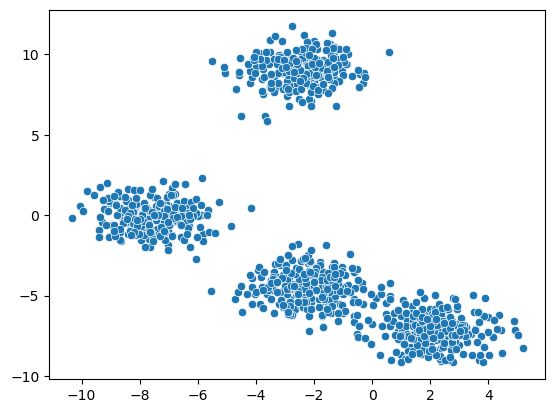

In [4]:
#visualize the data
sns.scatterplot(x=x[:,0],y=x[:,1])

In [5]:
#k-means clusterring
from sklearn.cluster import KMeans
k=4
k_mean=KMeans(
    n_clusters=k,
    random_state=42
)


<Axes: >

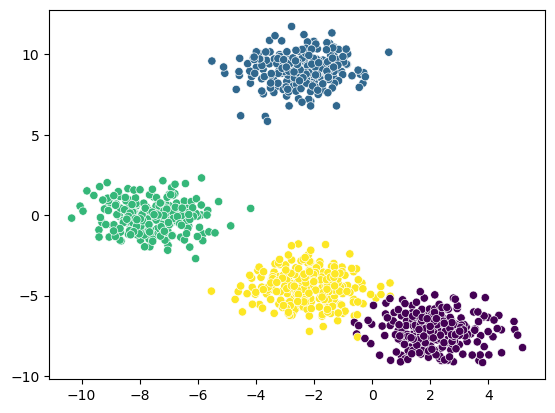

In [6]:
label=k_mean.fit_predict(x)
sns.scatterplot(x=x[:,0],y=x[:,1],c=label)

In [19]:
#choose our k-value elbow,sihouettee score
wcss=[]
for k in range(1,21):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(x)
    wcss.append(kmeans.inertia_)

<Axes: >

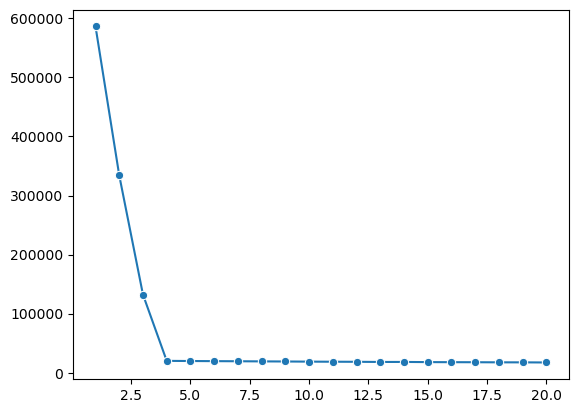

In [9]:
sns.lineplot(x=range(1,21),y=wcss,marker='o')

In [10]:
#kneed module
!pip install kneed 
#with the help of this we dont need to manually find the k value 

In [15]:
from kneed import KneeLocator

In [16]:
Knee=KneeLocator(range(1,21),wcss,curve="convex",direction="decreasing")
print("optimal K=",Knee.elbow)

optimal K= 4


In [23]:
#silhouette score
from sklearn.metrics import silhouette_score
ss=[]
for k in range(2,21):
    kmeans=KMeans(n_clusters=k)
    lables=kmeans.fit_predict(x)
    score=silhouette_score(x,lables)
    ss.append(score)

In [ ]:
#plot -k &ss
sn